# Import

In [67]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import numpy as np

# Remonte de deux niveaux (si ton notebook est dans /notebooks/exploration.ipynb)
# pour atteindre la racine du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from config.config import *

# Traitement des images labelisées

**Nous allons établir la stragtégie suivante :**
Sur la base de la clusterisation des photos par orientation, nous allons :
- utiliser la pseudo labelisation pour les images orientées top, car nous avons assez de 'normales' et de 'cancéreuses'.
- utiliser ??? pour les orientations side et face, pour lesquelles nous avons 

## Récupération de la donnée

In [68]:
# récupération des images clusterisées par orientation
df_images = pd.read_parquet(image_orientation)
df_images.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,"[0.40974900126457214, 0.8732983469963074, 0.17...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,side,cancer,0,side
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,"[1.192965030670166, 1.1314507722854614, 0.1077...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,"[0.4946941137313843, 0.4560645818710327, 0.174...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,"[0.4919051229953766, 0.35454875230789185, 0.39...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top


In [69]:
# dataframe des images 'TOP' cancéreuses
df_images_cancer_top= df_images[(df_images['orientation'] == 'top') & (df_images['type'] == 'cancer')]
df_images_cancer_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,"[1.192965030670166, 1.1314507722854614, 0.1077...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,"[0.4946941137313843, 0.4560645818710327, 0.174...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,"[0.4919051229953766, 0.35454875230789185, 0.39...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
9,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,"[0.8727291822433472, 0.7392463088035583, 0.012...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top


In [70]:
# dataframe des images 'TOP' normales
df_images_normal_top= df_images[(df_images['orientation'] == 'top') & (df_images['type'] == 'normal')]
df_images_normal_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
50,0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg,"[0.666938304901123, 0.8587964177131653, 0.0786...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
51,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,"[0.27638107538223267, 1.021559715270996, 0.096...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
52,11825cf3-9b35-42d3-ac99-21f26dd2f94e.jpg,"[0.24565695226192474, 0.7865098714828491, 0.11...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
53,14703976-0467-4acb-ade4-8a375ebfd4f9.jpg,"[0.6598442196846008, 0.12885765731334686, 0.61...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
54,1953e998-29b8-4d36-975f-007c4fcb84a3.jpg,"[0.19154807925224304, 0.3241497278213501, 0.31...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top


In [71]:
# dataframe images 'TOP' non labelisées
df_images_unknown_top = df_images[(df_images['weak_orientation'] == 'top') & (df_images['type'] == 'unknown')]
df_images_unknown_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
101,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,"[0.36736008524894714, 0.7256330251693726, 0.49...",NaN,unknown,unknown,2,top
102,00455a62-f79f-4072-9a23-4951e759acdc.jpg,"[0.4033546447753906, 0.5182491540908813, 0.215...",NaN,unknown,unknown,2,top
103,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,"[0.3427850902080536, 0.9386187195777893, 0.403...",NaN,unknown,unknown,2,top
106,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,"[0.39659130573272705, 0.6688651442527771, 0.39...",NaN,unknown,unknown,2,top
110,01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg,"[0.9405089616775513, 1.1057313680648804, 0.056...",NaN,unknown,unknown,2,top


In [72]:
# dataframe entrainement image cancers et normales
df = pd.concat([df_images_cancer_top,df_images_normal_top],ignore_index=True)
df.describe(include='all')

,name,features,path,orientation,type,cluster_label,weak_orientation
count,70,70,70,70,70,70.000000,70
unique,70,70,70,1,2,NaN,1
top,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,NaN,top
freq,1,1,1,70,48,NaN,70
mean,NaN,NaN,NaN,NaN,NaN,1.985714,NaN
std,NaN,NaN,NaN,NaN,NaN,0.119523,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,2.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,2.000000,NaN


In [73]:
df['type'] = df['type'].map({'cancer':1,
                      'normal' : 0})
df = df[['name','path','type']]

In [74]:
df.head()

,name,path,type
0,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
1,0f718241-8f63-4b55-81ce-315324b51069.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
2,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
3,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
4,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1


## Entrainement du modèle

In [75]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    stratify=df["type"],
    random_state=42
)
 

In [76]:
from torch.utils.data import Dataset
from PIL import Image

class BrainMRIDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "type"]

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        return img, label


In [77]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [78]:
from torch.utils.data import DataLoader

train_dataset = BrainMRIDataset(df_train, train_transform)
val_dataset   = BrainMRIDataset(df_val, train_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [79]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(pretrained=True)

# Gèle les couches convolutionnelles
for param in model.parameters():
    param.requires_grad = False

#remplace la couche finale du resnet par une couche de 2 choix
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


c:\Users\Fabien\Desktop\OC\P10\BrainScanAI\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Fabien\Desktop\OC\P10\BrainScanAI\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [80]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [81]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "f1": f1_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred)
    }

In [82]:
epochs = 15
f1_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, val_loader)
    
    train_loss_history.append(train_loss)
    val_loss_history.append(metrics['loss'])
    f1_history.append(metrics['f1'])
    
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {metrics['loss']:.4f} | "
        f"F1: {metrics['f1']:.3f} | "
        f"Acc: {metrics['accuracy']:.3f}"
    )

Epoch 1/15 | Train Loss: 0.7242 | Val Loss: 0.5027 | F1: 0.000 | Acc: 0.714
Epoch 2/15 | Train Loss: 0.4462 | Val Loss: 0.4981 | F1: 0.000 | Acc: 0.714
Epoch 3/15 | Train Loss: 0.3628 | Val Loss: 0.3394 | F1: 0.667 | Acc: 0.857
Epoch 4/15 | Train Loss: 0.2991 | Val Loss: 0.3819 | F1: 0.667 | Acc: 0.857
Epoch 5/15 | Train Loss: 0.2549 | Val Loss: 0.3593 | F1: 0.667 | Acc: 0.857
Epoch 6/15 | Train Loss: 0.2458 | Val Loss: 0.2306 | F1: 0.857 | Acc: 0.929
Epoch 7/15 | Train Loss: 0.1642 | Val Loss: 0.3284 | F1: 0.667 | Acc: 0.857
Epoch 8/15 | Train Loss: 0.2416 | Val Loss: 0.2362 | F1: 0.667 | Acc: 0.857
Epoch 9/15 | Train Loss: 0.2064 | Val Loss: 0.2191 | F1: 1.000 | Acc: 1.000
Epoch 10/15 | Train Loss: 0.1522 | Val Loss: 0.2051 | F1: 0.857 | Acc: 0.929
Epoch 11/15 | Train Loss: 0.1569 | Val Loss: 0.1962 | F1: 1.000 | Acc: 1.000
Epoch 12/15 | Train Loss: 0.1864 | Val Loss: 0.1965 | F1: 0.857 | Acc: 0.929
Epoch 13/15 | Train Loss: 0.1195 | Val Loss: 0.1840 | F1: 1.000 | Acc: 1.000
Epoch 14

## Visualisation des metrics

In [83]:
import numpy as np

np.mean(f1_history[-5:])


np.float64(0.9428571428571428)

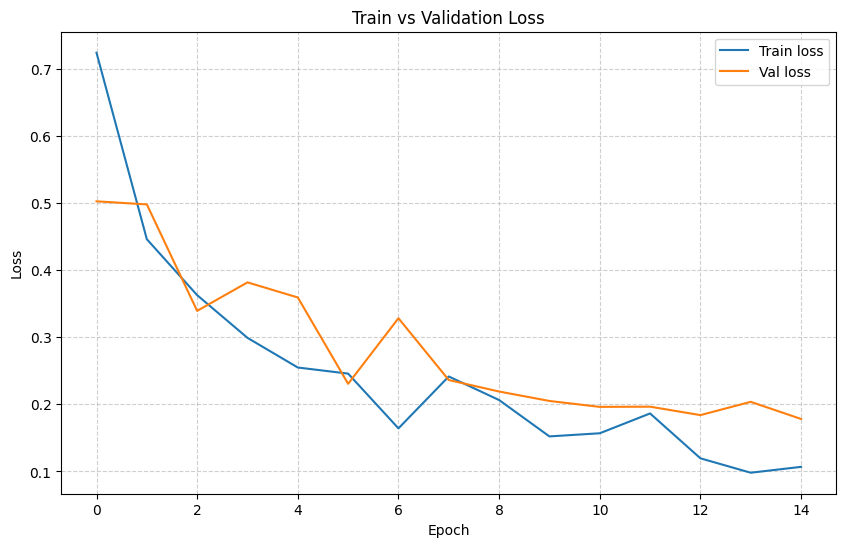

In [84]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label="Train loss")
plt.plot(val_loss_history, label="Val loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

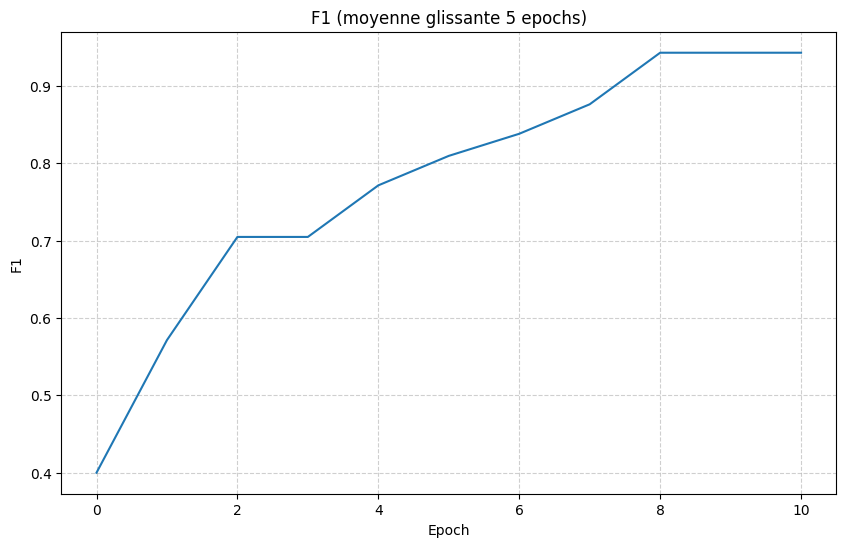

In [85]:
def moving_average(x, k=5):
    return np.convolve(x, np.ones(k)/k, mode="valid")

plt.figure(figsize=(10, 6))
plt.plot(moving_average(f1_history, 5))
plt.title("F1 (moyenne glissante 5 epochs)")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Matrice de Confusion**
Visualisation des performances du modèle sur le jeu de validation.

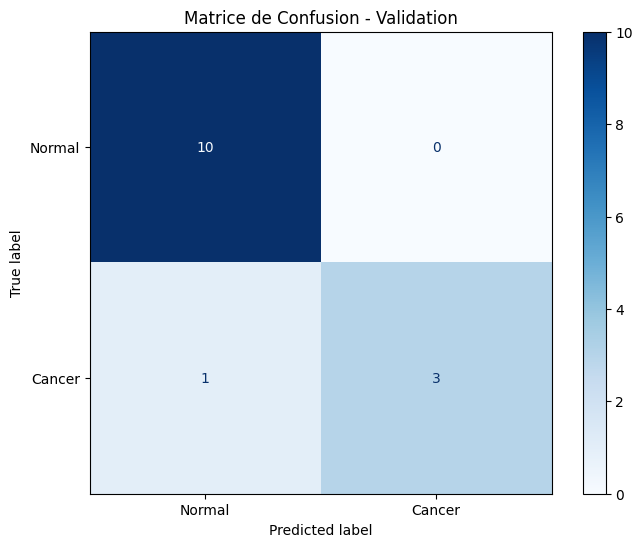

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Récupération des prédictions sur le jeu de validation
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Création de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
labels = ['Normal', 'Cancer']

# Affichage
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matrice de Confusion - Validation')
plt.show()

# Traitement des images non labelisés

## Récupération des données

In [87]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [88]:
df_image_orientation = pd.read_parquet(image_orientation)
df_image_orientation = df_image_orientation[(df_image_orientation['weak_orientation'] == 'top') & (df_image_orientation['type'] == 'unknown')]
df_image_orientation.head()
df_image_orientation.shape

(768, 7)

In [89]:
df_image_orientation.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
101,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,"[0.36736008524894714, 0.7256330251693726, 0.49...",NaN,unknown,unknown,2,top
102,00455a62-f79f-4072-9a23-4951e759acdc.jpg,"[0.4033546447753906, 0.5182491540908813, 0.215...",NaN,unknown,unknown,2,top
103,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,"[0.3427850902080536, 0.9386187195777893, 0.403...",NaN,unknown,unknown,2,top
106,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,"[0.39659130573272705, 0.6688651442527771, 0.39...",NaN,unknown,unknown,2,top
110,01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg,"[0.9405089616775513, 1.1057313680648804, 0.056...",NaN,unknown,unknown,2,top


C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\00455a62-f79f-4072-9a23-4951e759acdc.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg


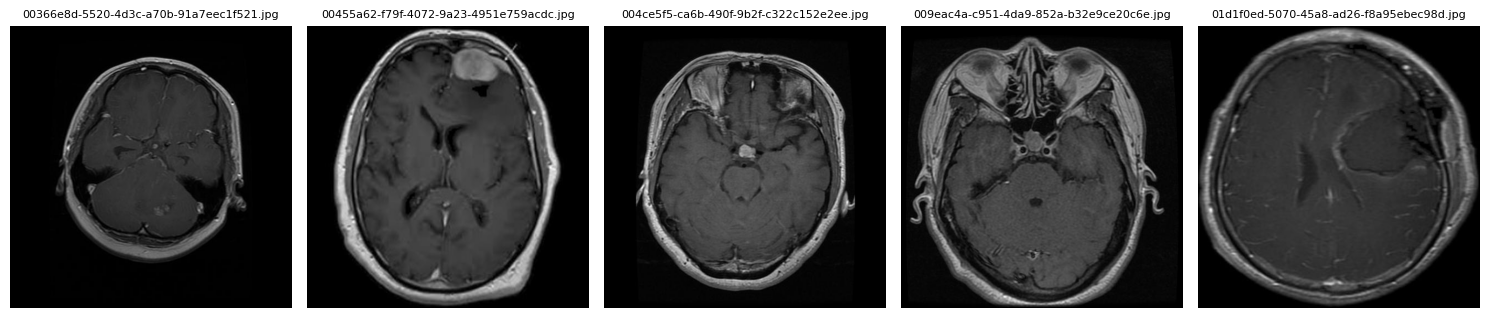

In [90]:
images_sans_label_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "sans_label"

# Créer une grille 1x5
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
axes = axes.flatten()

n_display = min(len(df_image_orientation), len(axes))
for idx, img_name in enumerate(df_image_orientation['name'][:n_display]):
    img_path = images_sans_label_dir / img_name
    print(img_path)
    img = Image.open(img_path)
    axes[idx].imshow(img)  # Sans cmap='gray' pour afficher en couleur
    axes[idx].set_title(img_name, fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [91]:
model.eval()

unlabeled = []


with torch.no_grad():
    for image_name in tqdm(df_image_orientation['name'], desc= 'Pseudo-labeling : '):

        img = Image.open(BASE_DIR / 'mri_dataset_brain_cancer_oc' / 'sans_label' / image_name).convert('RGB')

        x = transform(img).unsqueeze(0).to(device)

        logits = model(x)
        # On utilise softmax car le modèle a 2 sorties (CrossEntropyLoss)
        probs = torch.softmax(logits, dim=1)
        prob = probs[0, 1].item() # Probabilité de la classe 'cancer' (index 1)

        unlabeled.append({'name' : image_name,
                          'prob_cancer' : prob})
        
df_unlabeled = pd.DataFrame(unlabeled)

Pseudo-labeling : 100%|██████████| 768/768 [00:24<00:00, 31.09it/s]


In [106]:
TH_HIGH = 0.95
TH_LOW = 0.05

df_pseudo = df_unlabeled[
    (df_unlabeled["prob_cancer"] >= TH_HIGH) |
    (df_unlabeled["prob_cancer"] <= TH_LOW)
].copy()

# Attribution du label en fonction de la probabilité
df_pseudo['type'] = df_pseudo['prob_cancer'].apply(lambda x: 1 if x >= TH_HIGH else 0)

df_pseudo['path'] = df_pseudo.apply(lambda row : str(BASE_DIR / 'mri_dataset_brain_cancer_oc' / 'sans_label' / row['name']),axis=1)

df_pseudo ['origin'] = 'pseudo_labeled'
print(f"Nombre d'images retenues pour le pseudo-labeling : {len(df_pseudo)} / {len(df_unlabeled)}")
print("Répartition des pseudo-labels :")
print(df_pseudo['type'].value_counts())

df_pseudo.head()

Nombre d'images retenues pour le pseudo-labeling : 266 / 768
Répartition des pseudo-labels :
type
1    149
0    117
Name: count, dtype: int64


,name,prob_cancer,type,path,origin
0,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,0.990245,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
2,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,0.968975,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
3,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,0.981650,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
5,0208c07c-bc4b-4741-ad0f-d5beeb18cc52.jpg,0.974943,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
7,030d0b45-ee70-41f9-9e56-2581052b2c18.jpg,0.995950,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled


In [108]:
sample_positive_test = df_pseudo[df_pseudo['type']==1][:5]
sample_positive_test

,name,prob_cancer,type,path,origin
0,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,0.990245,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
2,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,0.968975,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
3,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,0.981650,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
5,0208c07c-bc4b-4741-ad0f-d5beeb18cc52.jpg,0.974943,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
7,030d0b45-ee70-41f9-9e56-2581052b2c18.jpg,0.995950,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled


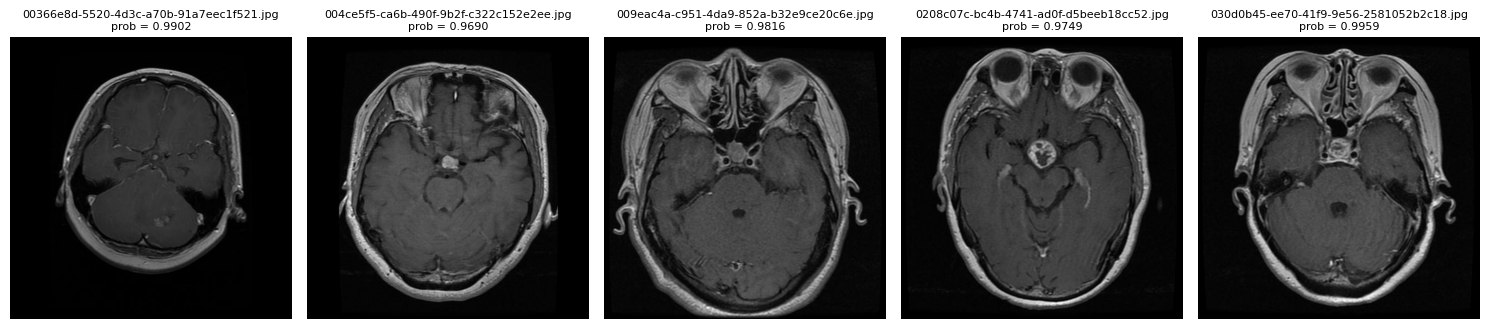

In [109]:
# On limite à 5 images pour correspondre à la grille 1x5
n_display = min(len(sample_positive_test), 5)

if n_display == 0:
    print("Aucune image positive trouvée.")
else:
    fig, axes = plt.subplots(1, n_display, figsize=(15, 6))
    
    # Gestion du cas où il n'y a qu'une seule image (axes n'est pas une liste)
    if n_display == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Utilisation de iterrows() pour accéder aux données proprement (évite les erreurs d'index .loc)
    for idx, (original_idx, row) in enumerate(sample_positive_test.head(n_display).iterrows()):
        img_name = row['name']
        prob = row['prob_cancer']
        img_path = images_sans_label_dir / img_name
        
        img = Image.open(img_path)
        axes[idx].imshow(img)
        # Utilisation de doubles quotes pour l'f-string et affichage de la probabilité formatée
        axes[idx].set_title(f"{img_name}\nprob = {prob:.4f}", fontsize=8)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

In [110]:
df.head()
df.shape

(70, 4)

In [111]:
df_pseudo.drop(columns=['prob_cancer'],inplace=True)
df_pseudo.head()
df_pseudo.shape

(266, 4)

In [112]:

df['origin'] = 'labeled'
df_merged = pd.concat([df,df_pseudo])

df_merged.shape

(336, 4)